# FrozenLake PPO

## 实验目标

这个 notebook 使用 `PPO` 作为现代策略优化方法，对 FrozenLake 做一个对照实验。它的目的不是证明 `PPO` 是这个环境里最自然的方法，而是让读者看到：同一个小型离散环境，既可以用表格型 `Q-Learning` 解决，也可以用更现代的策略梯度路线求解。

## 为什么这里仍然做 PPO

FrozenLake 本身更适合讲解表格方法，这一点不会改变。之所以仍然加一个 `PPO` 版本，是因为本仓库整体的方法路线偏向现代强化学习工程实践，而 `PPO` 正是其中最常用、最容易并行化、也最容易利用设备算力的方法之一。

因此，这个实验的定位是：

- 不是 FrozenLake 的最简洁主线解法
- 而是一个现代算法对照实验
- 用来说明 `PPO` 即使面对很小的离散环境，也能够学到有效策略
- 同时也能让读者理解，为什么在更复杂的任务上，仓库会优先选择 `PPO`

## 设备与并行说明

- 本实验默认使用 `CPU`
- 如果本机具备可用的 `CUDA` 或 `MPS`，网络训练部分可以切换到对应设备
- 环境采样采用并行环境，以体现 `PPO` 的工程优势

虽然 FrozenLake 很小，不一定需要 GPU，但这个 notebook 会保留设备自动选择逻辑和并行采样结构。这样做的目的是让它和后面更复杂任务里的 `PPO` 实验保持一致。

In [7]:
import os
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.distributions import Categorical
from tqdm.auto import tqdm

In [8]:
ENV_ID = "FrozenLake-v1"
AVAILABLE_CPUS = os.cpu_count() or 1
NUM_ENVS = min(AVAILABLE_CPUS, 24)
TOTAL_UPDATES = 400
POSTFIX_UPDATE_INTERVAL = 10
ROLLOUT_STEPS = 128
EPOCHS = 4
MINIBATCH_SIZE = 512
LEARNING_RATE = 2.5e-4
GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP_EPS = 0.2
ENTROPY_COEF = 0.01
VALUE_COEF = 0.5
MAX_GRAD_NORM = 0.5
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

DEVICE

device(type='mps')

## 参数选择说明

这里的参数选择围绕两个目标：

- 保持一个标准的离散动作 `PPO` 训练结构
- 在 FrozenLake 这样的小环境里尽量让训练过程稳定可观察

核心参数解释如下：

- `NUM_ENVS = min(os.cpu_count(), 24)`：并行环境数量跟随本机 CPU 数量，但做一个上限，避免为了并行把调度开销放大得过头
- `ROLLOUT_STEPS = 128`：每次更新前收集的轨迹长度
- `TOTAL_UPDATES = 400`：在不把运行时间拉得太离谱的前提下，把训练预算提高到更容易收敛的水平
- `POSTFIX_UPDATE_INTERVAL = 10`：进度条后缀不在每个 update 都刷新，减少 notebook 前端刷新压力
- `EPOCHS = 4`：每批 rollout 数据做 4 轮优化，是 PPO 的常见起点
- `CLIP_EPS = 0.2`：控制策略更新幅度，避免一次更新走得过远
- `ENTROPY_COEF = 0.01`：鼓励探索，避免策略过早塌缩
- `GAE_LAMBDA = 0.95`：用于优势估计，平衡偏差与方差

如果后续训练曲线仍然偏抖，最常见的调参方向通常是：

- 增加 `TOTAL_UPDATES`
- 调整 `ENTROPY_COEF`
- 适度减小学习率
- 增加并行环境数或 rollout 长度

In [9]:
def make_env(seed_offset):
    def thunk():
        env = gym.make(ENV_ID, is_slippery=True)
        env.reset(seed=SEED + seed_offset)
        return env
    return thunk


env_fns = [make_env(i) for i in range(NUM_ENVS)]
try:
    envs = gym.vector.AsyncVectorEnv(env_fns)
    VEC_ENV_MODE = "async"
except Exception:
    envs = gym.vector.SyncVectorEnv(env_fns)
    VEC_ENV_MODE = "sync"
obs_shape = envs.single_observation_space.n
action_dim = envs.single_action_space.n

In [10]:
def one_hot(states, num_states):
    return torch.nn.functional.one_hot(states.long(), num_classes=num_states).float()


class ActorCritic(nn.Module):
    def __init__(self, num_states, num_actions):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(num_states, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
        )
        self.policy_head = nn.Linear(64, num_actions)
        self.value_head = nn.Linear(64, 1)

    def forward(self, x):
        hidden = self.shared(x)
        return self.policy_head(hidden), self.value_head(hidden).squeeze(-1)

    def get_action_and_value(self, states, actions=None):
        logits, values = self(states)
        dist = Categorical(logits=logits)
        if actions is None:
            actions = dist.sample()
        return actions, dist.log_prob(actions), dist.entropy(), values


agent = ActorCritic(obs_shape, action_dim).to(DEVICE)
optimizer = torch.optim.Adam(agent.parameters(), lr=LEARNING_RATE)

In [11]:
obs_buffer = torch.zeros((ROLLOUT_STEPS, NUM_ENVS), dtype=torch.long)
actions_buffer = torch.zeros((ROLLOUT_STEPS, NUM_ENVS), dtype=torch.long)
logprobs_buffer = torch.zeros((ROLLOUT_STEPS, NUM_ENVS), dtype=torch.float32)
rewards_buffer = torch.zeros((ROLLOUT_STEPS, NUM_ENVS), dtype=torch.float32)
dones_buffer = torch.zeros((ROLLOUT_STEPS, NUM_ENVS), dtype=torch.float32)
values_buffer = torch.zeros((ROLLOUT_STEPS, NUM_ENVS), dtype=torch.float32)

In [12]:
next_obs, info = envs.reset(seed=SEED)
next_obs = torch.tensor(next_obs, dtype=torch.long)
next_done = torch.zeros(NUM_ENVS, dtype=torch.float32)

episode_successes = []
recent_successes = []
mean_rewards = []
mean_entropies = []

progress_bar = tqdm(range(TOTAL_UPDATES), desc="PPO updates")

for update in progress_bar:
    for step in range(ROLLOUT_STEPS):
        obs_buffer[step] = next_obs
        dones_buffer[step] = next_done

        with torch.no_grad():
            encoded_obs = one_hot(next_obs.to(DEVICE), obs_shape)
            action, logprob, entropy, value = agent.get_action_and_value(encoded_obs)

        actions_buffer[step] = action.cpu()
        logprobs_buffer[step] = logprob.cpu()
        values_buffer[step] = value.cpu()

        next_obs_np, reward, terminated, truncated, info = envs.step(action.cpu().numpy())
        done = np.logical_or(terminated, truncated)

        rewards_buffer[step] = torch.tensor(reward, dtype=torch.float32)
        next_obs = torch.tensor(next_obs_np, dtype=torch.long)
        next_done = torch.tensor(done, dtype=torch.float32)

        for env_idx, done_flag in enumerate(done):
            if done_flag:
                success_value = float(reward[env_idx] > 0)
                episode_successes.append(success_value)
                recent_successes.append(success_value)
                if len(recent_successes) > 50:
                    recent_successes.pop(0)

    with torch.no_grad():
        next_value = agent.get_action_and_value(one_hot(next_obs.to(DEVICE), obs_shape))[3].cpu()
        advantages = torch.zeros_like(rewards_buffer)
        lastgaelam = 0
        for t in reversed(range(ROLLOUT_STEPS)):
            if t == ROLLOUT_STEPS - 1:
                nextnonterminal = 1.0 - next_done
                nextvalues = next_value
            else:
                nextnonterminal = 1.0 - dones_buffer[t + 1]
                nextvalues = values_buffer[t + 1]
            delta = rewards_buffer[t] + GAMMA * nextvalues * nextnonterminal - values_buffer[t]
            lastgaelam = delta + GAMMA * GAE_LAMBDA * nextnonterminal * lastgaelam
            advantages[t] = lastgaelam
        returns = advantages + values_buffer

    b_obs = obs_buffer.reshape(-1)
    b_actions = actions_buffer.reshape(-1)
    b_logprobs = logprobs_buffer.reshape(-1)
    b_advantages = advantages.reshape(-1)
    b_returns = returns.reshape(-1)
    b_values = values_buffer.reshape(-1)

    batch_size = NUM_ENVS * ROLLOUT_STEPS
    indices = np.arange(batch_size)
    entropy_epoch = []

    for epoch in range(EPOCHS):
        np.random.shuffle(indices)
        for start in range(0, batch_size, MINIBATCH_SIZE):
            end = start + MINIBATCH_SIZE
            mb_idx = indices[start:end]

            encoded_obs = one_hot(b_obs[mb_idx].to(DEVICE), obs_shape)
            _, new_logprob, entropy, new_value = agent.get_action_and_value(
                encoded_obs,
                b_actions[mb_idx].to(DEVICE),
            )

            log_ratio = new_logprob - b_logprobs[mb_idx].to(DEVICE)
            ratio = log_ratio.exp()

            mb_advantages = b_advantages[mb_idx].to(DEVICE)
            mb_advantages = (mb_advantages - mb_advantages.mean()) / (mb_advantages.std() + 1e-8)

            pg_loss1 = -mb_advantages * ratio
            pg_loss2 = -mb_advantages * torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS)
            policy_loss = torch.max(pg_loss1, pg_loss2).mean()

            value_loss = 0.5 * ((new_value - b_returns[mb_idx].to(DEVICE)) ** 2).mean()
            entropy_loss = entropy.mean()
            loss = policy_loss + VALUE_COEF * value_loss - ENTROPY_COEF * entropy_loss

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), MAX_GRAD_NORM)
            optimizer.step()

            entropy_epoch.append(float(entropy_loss.detach().cpu()))

    current_reward = float(rewards_buffer.mean().item())
    current_entropy = float(np.mean(entropy_epoch))
    mean_rewards.append(current_reward)
    mean_entropies.append(current_entropy)
    recent_success = float(np.mean(recent_successes)) if len(recent_successes) > 0 else 0.0
    if update % POSTFIX_UPDATE_INTERVAL == 0 or update == TOTAL_UPDATES - 1:
        progress_bar.set_postfix(reward=f"{current_reward:.3f}", entropy=f"{current_entropy:.3f}", success=f"{recent_success:.3f}")

envs.close()

PPO updates:   0%|          | 0/400 [00:00<?, ?it/s]

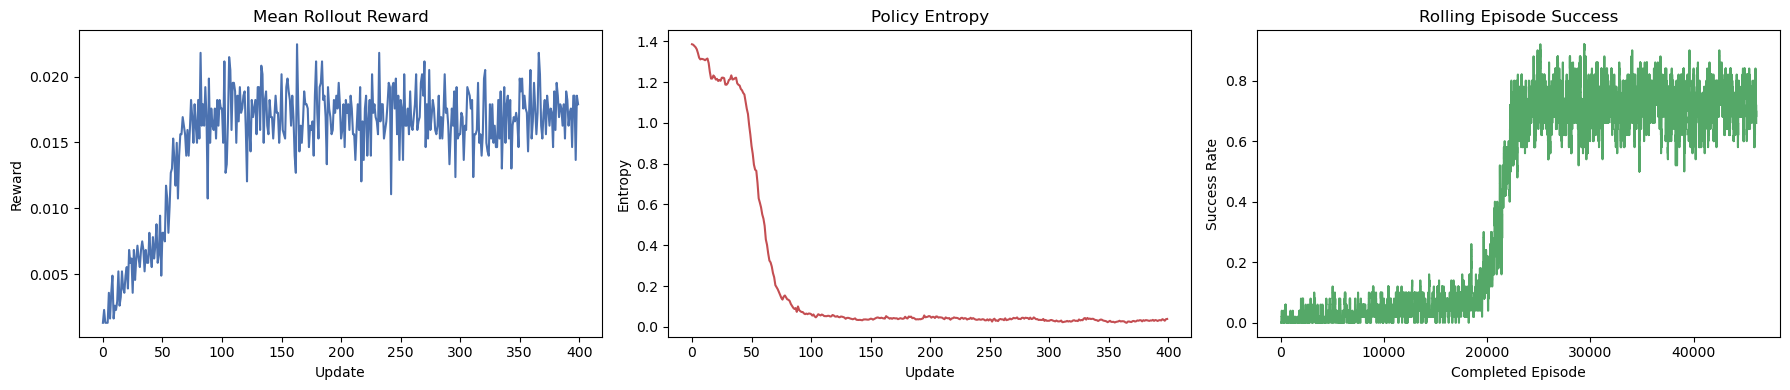

In [13]:
success_df = pd.Series(episode_successes, dtype=float)
success_rolling = success_df.rolling(50).mean() if len(success_df) >= 50 else success_df

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(mean_rewards, color="#4c72b0")
axes[0].set_title("Mean Rollout Reward")
axes[0].set_xlabel("Update")
axes[0].set_ylabel("Reward")

axes[1].plot(mean_entropies, color="#c44e52")
axes[1].set_title("Policy Entropy")
axes[1].set_xlabel("Update")
axes[1].set_ylabel("Entropy")

axes[2].plot(success_rolling, color="#55a868")
axes[2].set_title("Rolling Episode Success")
axes[2].set_xlabel("Completed Episode")
axes[2].set_ylabel("Success Rate")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ppo_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
with torch.no_grad():
    all_states = torch.arange(obs_shape, dtype=torch.long)
    logits, values = agent(one_hot(all_states.to(DEVICE), obs_shape))
    policy = torch.softmax(logits, dim=-1).cpu().numpy()
    state_values = values.cpu().numpy().reshape(4, 4)
    action_symbols = np.array(["L", "D", "R", "U"])
    greedy_policy = action_symbols[np.argmax(policy, axis=1)].reshape(4, 4)

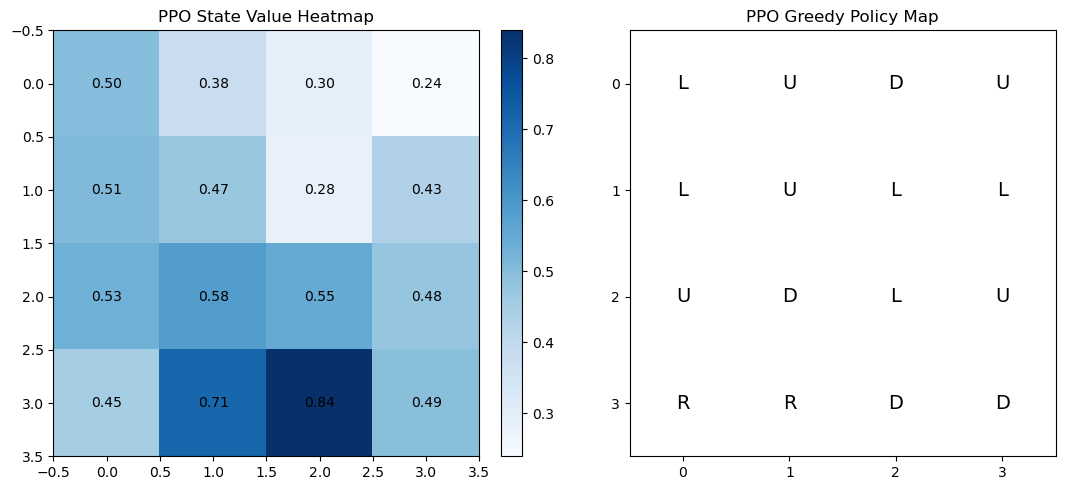

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(state_values, cmap="Blues")
axes[0].set_title("PPO State Value Heatmap")
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f"{state_values[i, j]:.2f}", ha="center", va="center", color="black")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].imshow(np.zeros((4, 4)), cmap="Greys", vmin=0, vmax=1)
axes[1].set_title("PPO Greedy Policy Map")
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, greedy_policy[i, j], ha="center", va="center", color="black", fontsize=14)
axes[1].set_xticks(range(4))
axes[1].set_yticks(range(4))

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ppo_policy_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
metrics = pd.DataFrame(
    {
        "metric": [
            "device",
            "num_envs",
            "vec_env_mode",
            "total_updates",
            "mean_rollout_reward_last_10",
            "mean_entropy_last_10",
            "episode_success_mean_last_50",
        ],
        "value": [
            str(DEVICE),
            NUM_ENVS,
            VEC_ENV_MODE,
            TOTAL_UPDATES,
            float(np.mean(mean_rewards[-10:])),
            float(np.mean(mean_entropies[-10:])),
            float(success_df.tail(50).mean()) if len(success_df) > 0 else 0.0,
        ],
    }
)
metrics

,metric,value
0,device,mps
1,num_envs,24
2,vec_env_mode,async
3,total_updates,400
4,mean_rollout_reward_last_10,0.017122
5,mean_entropy_last_10,0.033467
6,episode_success_mean_last_50,0.66


In [17]:
metrics.to_csv(RESULTS_DIR / "ppo_metrics.csv", index=False)
pd.DataFrame(policy).to_csv(RESULTS_DIR / "ppo_policy_table.csv", index=False)

print(f"Device: {DEVICE}")
print(f"Parallel envs: {NUM_ENVS}")
print(f"Vector env mode: {VEC_ENV_MODE}")
print(f"Last 10 mean rollout reward: {np.mean(mean_rewards[-10:]):.4f}")
print(f"Last 10 mean entropy: {np.mean(mean_entropies[-10:]):.4f}")
if len(success_df) > 0:
    print(f"Last 50 episode success mean: {success_df.tail(50).mean():.4f}")
print(f"Saved results to: {RESULTS_DIR.resolve()}")

Device: mps
Parallel envs: 24
Vector env mode: async
Last 10 mean rollout reward: 0.0171
Last 10 mean entropy: 0.0335
Last 50 episode success mean: 0.6600
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/01-frozenlake-tabular-q-learning/results


## 结果解读

阅读这个 notebook 时，重点看三件事：

- `Mean Rollout Reward` 是否随着更新逐步上升
- `Policy Entropy` 是否从较高水平逐渐下降，说明策略在从探索过渡到更确定的决策
- 最终的状态价值图和贪心策略图是否形成一致的前进方向

如果 PPO 能在这个小环境里学到较好的策略，它就能作为一个很好的现代方法对照案例。但从方法论角度看，FrozenLake 仍然更适合先用 `Q-Learning` 讲基础，再用 `PPO` 展示现代工程路线。